# Analysis of Sample OREX-800107-0: Plotting the PSFD from Longest Axes

In [33]:
import numpy as np
import pandas as pd
import csv
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit  # used for power law plotting
from scipy.special import gammaincc

Reading the CSV file for the longest axis for the PSFD:
------------------------------------------------------

In [19]:
longest_axes = []

with open("ParticleAxes.csv", "r") as f:
    reader = csv.reader(f)
    next(reader)  # skip header
    for row in reader:
        try:
            long_axis = float(row[1])  # column 1 = longest axis
            longest_axes.append(long_axis)
        except:
            continue  # skip bad rows (if any)

inertia_longest_axes = np.array(longest_axes)

Plotting the PSFD for OREX-800107-0:
-----------------------------------

Power-Law plot:
--------------

In [171]:
def PowerLaw(x, a, b):
    '''
        This function computes the power law of a given data set
        
        inputs:
            x: np.array
                the data (longest axes of particles)
            a: float
                the y-intercept of the power-law fit
            b: float
                the slope of the power-law fit
                
        outputs: 
            PL: float
                the power law
    '''
    
    PL = a * x ** b

    return PL

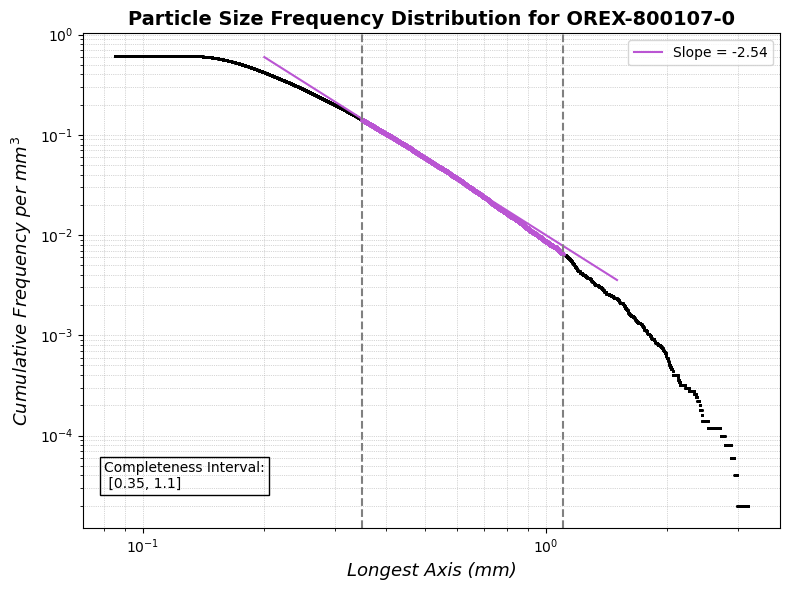

In [185]:
# NO ERROR CALCULATION

# hard-code total analyzed volume of the sample
# used to normalize the counts
SampleVolume = 5e4   # in mm^3

# define the x-range for fitting the linear slope accurately
xmin_fit = 0.35
xmax_fit = 1.1

# define plot interval (wider than fit interval)
xmin_plot = 0.2
xmax_plot = 1.5

# create log-spaced bins for histogram plotting
bins = np.logspace(np.log10(min(inertia_longest_axes)), np.log10(max(inertia_longest_axes)), 10000)
counts, BinEdges = np.histogram(inertia_longest_axes, bins=bins)
# determining the cumulative sum from the smallest to the largest particle
CumulativeCounts = np.cumsum(counts[::-1])[::-1] / SampleVolume  # per mm³
BinCenters = (BinEdges[:-1] + BinEdges[1:]) / 2

# ignore zeros in the counts due to loglog space
mask = CumulativeCounts > 0
x = BinCenters[mask]
y = CumulativeCounts[mask]

# mask the data to be within the selected x-range for accurate fitting
# used to find the slope only based on the portion of the plot that is linear
mask2 = (x >= xmin_fit) & (x <= xmax_fit)
x_fit = x[mask2]
y_fit = y[mask2]

# fit the curve to the dataset
parameters, _ = curve_fit(PowerLaw, x_fit, y_fit, p0=[0.12, -2])
a, b = parameters

# compute y=mx+b line for slope
x_line = np.logspace(np.log10(xmin_plot), np.log10(xmax_plot), 200)
y_line = PowerLaw(x_line, a, b)

# plot the PSFD
plt.figure(figsize=(8,6))
plt.loglog(x, y, 'o', ms=1, color='black')

# highlight portion of the data that contributes to the slope
plt.loglog(x_fit, y_fit, 'o', ms=2, color='mediumorchid')
plt.loglog(x_line, y_line, ms=1, label=f"Slope = {b:.2f}", color='mediumorchid')

# labels and organization
plt.xlabel("Longest Axis (mm)", fontsize=13).set_style('italic')
plt.ylabel(f"Cumulative Frequency per $mm^3$", fontsize=13).set_style('italic')
plt.title("Particle Size Frequency Distribution for OREX-800107-0", fontsize=14, weight='bold')
plt.text(0.08,0.00003,f"Completeness Interval:\n [{xmin_fit}, {xmax_fit}]", bbox=dict(facecolor='none', edgecolor='black', boxstyle='square'))

plt.grid(True, which='both', linestyle=':', linewidth=0.5)
plt.axvline(x = xmin_fit, color = 'gray', linestyle='--')
plt.axvline(x = xmax_fit, color = 'gray', linestyle='--')
plt.legend()
plt.tight_layout()
plt.savefig('PSFD_OREX-800107-0_InertiaAxes_NoError.png', dpi=300)
plt.show()

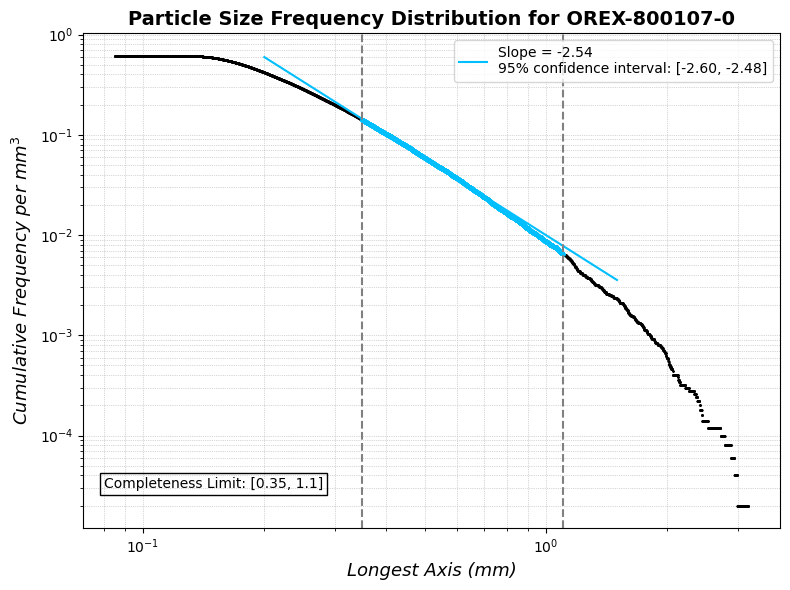

In [188]:
# CALCULATING ERROR WITH BOOTSTRAP METHOD FROM CLAUSSET ET AL.

# hard-code total volume of the sample (approximated)
SampleVolume = 5e4  # in mm^3

# define the x-range for fitting the linear slope accurately
xmin_fit = 0.35
xmax_fit = 1.1

# define plot interval (wider than fit interval)
xmin_plot = 0.2
xmax_plot = 1.5

# create log-spaced bins for histogram plotting
bins = np.logspace(np.log10(min(inertia_longest_axes)), np.log10(max(inertia_longest_axes)), 10000)
BinEdges, _ = np.histogram(inertia_longest_axes, bins=bins)
# determine the cumulative sum from the smallest to the largest particle
CumulativeCounts = np.cumsum(BinEdges[::-1])[::-1] / SampleVolume  # per mm³
BinCenters = (bins[:-1] + bins[1:]) / 2

# remove zero counts to avoid log errors
mask = CumulativeCounts > 0
x = BinCenters[mask]
y = CumulativeCounts[mask]

# mask the values for the slope to those previously defined
mask2 = (x >= xmin_fit) & (x <= xmax_fit)
x_fit = x[mask2]
y_fit = y[mask2]

# fit original data to get initial slope
parameteres, _ = curve_fit(PowerLaw, x_fit, y_fit, p0=[0.1, -2.1])
a_fit, b_fit = parameters

# compute the slope line for plotting
x_line = np.logspace(np.log10(xmin_plot), np.log10(xmax_plot), 100)
y_line = PowerLaw(x_line, a_fit, b_fit)

# loop through slope values to find uncertainty
B = 5000  # use at least 5000 for journal accuracy
BootstrapSlopes = []

for i in range(B):
    # create a randomized data set
    # less biased towards one part of the data
    sample = np.random.choice(inertia_longest_axes, size=len(inertia_longest_axes), replace=True)
    
    # compute histogram and cumulative counts with randomized data
    bins = np.logspace(np.log10(min(sample)), np.log10(max(sample)), 10000)
    BinEdges, i = np.histogram(sample, bins=bins)
    CumulativeCounts = np.cumsum(BinEdges[::-1])[::-1] / SampleVolume
    BinCenters = (bins[:-1] + bins[1:]) / 2

    # ensure there are no zero counts for log space
    mask3 = CumulativeCounts > 0
    x_bootstrap = BinCenters[mask3]
    y_bootstrap = CumulativeCounts[mask3]

    # ensure the x and y values are within the ranges for best-fit
    mask4 = (x_bootstrap >= xmin_fit) & (x_bootstrap <= xmax_fit)
    x_fit_bootstrap = x_bootstrap[mask4]
    y_fit_bootstrap = y_bootstrap[mask4]

    # try to fit the above power law to the bootstrap data
    try:
        parameters_bootstrap, _ = curve_fit(PowerLaw, x_fit_bootstrap, y_fit_bootstrap, p0=[0.1, -2.1])
        a_bootstrap, b_bootstrap = parameters_bootstrap
        BootstrapSlopes.append(b_bootstrap)
    # if the fit fails, move to the next bootstrap value
    except:
        continue 

# convert list to np array
BootstrapSlopes = np.array(BootstrapSlopes)
mean_slope = np.mean(BootstrapSlopes)
# define confidence intervals
# determine the +/- error for the slope
confidence_lower = np.percentile(BootstrapSlopes, 2.5)  # can change these percentiles
confidence_upper = np.percentile(BootstrapSlopes, 97.5)

# plot the PSFD
plt.figure(figsize=(8, 6))
plt.loglog(x, y, '.', ms=1, color='black')
# highlight the region of the data that corresponds to the best-fit slope
plt.loglog(x_fit, y_fit, 'o', ms=2, color='deepskyblue')

# plot best fit slope with bootstrap uncertainty
plt.loglog(x_line, y_line, ms=5, 
           label=f"Slope = {b_fit:.2f}\n95% confidence interval: [{confidence_lower:.2f}, {confidence_upper:.2f}]", color='deepskyblue')

# labels and organization
plt.xlabel('Longest Axis (mm)', fontsize=13).set_style('italic')
plt.ylabel('Cumulative Frequency per mm$^3$', fontsize=13).set_style('italic')
plt.title("Particle Size Frequency Distribution for OREX-800107-0", fontsize=14, weight='bold')
plt.text(0.08,0.00003, f"Completeness Limit: [{xmin_fit}, {xmax_fit}]", bbox=dict(facecolor='none', edgecolor='black', boxstyle='square')) 
plt.grid(which='both', linestyle=':', linewidth=0.5)
plt.axvline(x = xmin_fit, color = 'gray', linestyle='--')
plt.axvline(x = xmax_fit, color = 'gray', linestyle='--')
plt.legend()
plt.tight_layout()
plt.savefig('PSFD_OREX-800107-0_InertiaAxes_bootstrap.png', dpi=300)
plt.show()

Weibull Plot:
-------------

In [49]:
# Weibull CDF function (normalized to match cumulative counts)
def WeibullCDF(x, lam, k):
    # x: size
    # lam: scale parameter
    # k: shape parameter
    return np.exp(- (x / lam)**k)

# normalize CDF to cumulative particle count per mm³
def WeibullCDF_scaled(x, lam, k, scale):
    return scale * WeibullCDF(x, lam, k)

C:\Users\savan\AppData\Local\Temp\ipykernel_9984\1056245541.py:6: RuntimeWarning: invalid value encountered in power
  return np.exp(- (x / lam)**k)


Effective Weibull slope in log-log space over [0.3, 1.1]: -2.66


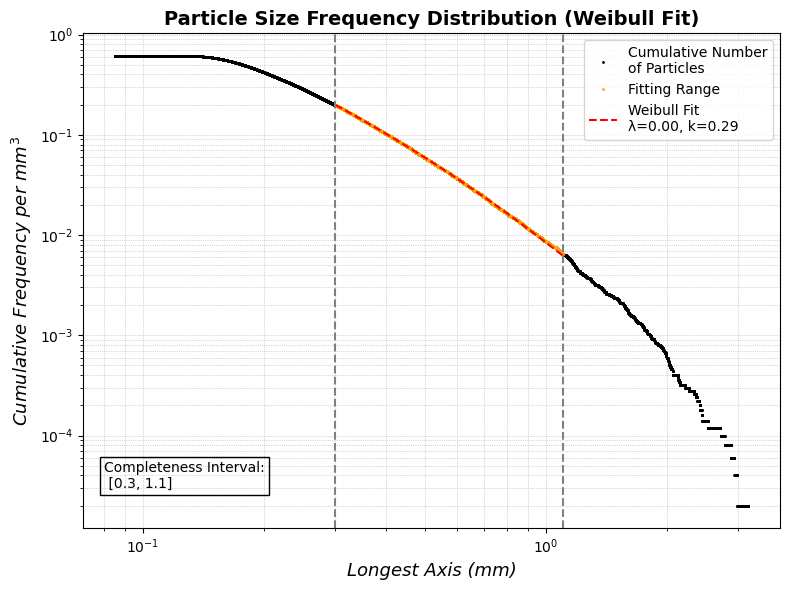

In [55]:
# hard-coded sample volume (in mm³)
SampleVolume = 5e4

# define fit range
xmin_fit = 0.3
xmax_fit = 1.1

# compute histogram
bins = np.logspace(np.log10(min(inertia_longest_axes)), np.log10(max(inertia_longest_axes)), 10000)
counts, BinEdges = np.histogram(inertia_longest_axes, bins=bins)
CumulativeCounts = np.cumsum(counts[::-1])[::-1] / SampleVolume  # per mm³
BinCenters = (BinEdges[:-1] + BinEdges[1:]) / 2

# mask out zero values
mask = CumulativeCounts > 0
x = BinCenters[mask]
y = CumulativeCounts[mask]

# fit range mask
mask2 = (x >= xmin_fit) & (x <= xmax_fit)
x_fit = x[mask2]
y_fit = y[mask2]

# fit Weibull to data
p0 = [1.0, 1.5, max(y_fit)]  # initial guesses: lam, k, scale
params, _ = curve_fit(WeibullCDF_scaled, x_fit, y_fit, p0=p0, maxfev=10000)
lam, k, scale = params

# generate Weibull curve
x_line = np.logspace(np.log10(xmin_fit), np.log10(xmax_fit), 100)
y_weibull = WeibullCDF_scaled(x_line, lam, k, scale)

plt.figure(figsize=(8,6))
plt.loglog(x, y, 'o', ms=1, label='Cumulative Number\nof Particles', color='black')
plt.loglog(x_fit, y_fit, 'o', ms=1, color='orange', label='Fitting Range')
plt.loglog(x_line, y_weibull, '--', label=f"Weibull Fit\nλ={lam:.2f}, k={k:.2f}", color='red')

plt.xlabel("Longest Axis (mm)", fontsize=13).set_style('italic')
plt.ylabel(f"Cumulative Frequency per $mm^3$", fontsize=13).set_style('italic')
plt.title("Particle Size Frequency Distribution (Weibull Fit)", fontsize=14, weight='bold')
plt.text(0.08, 0.00003, f"Completeness Interval:\n [{xmin_fit}, {xmax_fit}]", bbox=dict(facecolor='none', edgecolor='black', boxstyle='square'))

# Compute log-log slope (numerical derivative) over fit range
log_x = np.log10(x_line)
log_y = np.log10(y_weibull)

# Numerical derivative: dy/dx in log-log space
dlogy = np.diff(log_y)
dlogx = np.diff(log_x)
local_slopes = dlogy / dlogx

# compute average slope over the range
average_slope = np.mean(local_slopes)

print(f"Effective Weibull slope in log-log space over [{xmin_fit}, {xmax_fit}]: {average_slope:.2f}")

plt.grid(True, which='both', linestyle=':', linewidth=0.5)
plt.axvline(x=xmin_fit, color='gray', linestyle='--')
plt.axvline(x=xmax_fit, color='gray', linestyle='--')
plt.legend()
plt.tight_layout()
plt.savefig('PSFD_OREX-800107-0_InertiaAxes_WeibullFit.png')
plt.show()